In [1]:
import datetime
import datetime as dt

import numpy as np
from matplotlib import pyplot as plt
from netCDF4 import Dataset
import pandas as pd
from scipy.optimize import minimize
import xarray as xr

from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset

In [2]:
INPUT_DIR = "input_irrigation_2years"

In [3]:
irr_store = new_data_store("file", root=INPUT_DIR)

In [4]:
irr_store.list_data_ids()

['clms.zarr', 'irrigation_input.zarr', 'era5.zarr', 'landcover2020global.zarr']

In [5]:
ds = irr_store.open_data("irrigation_input.zarr")

In [6]:
ds

<xarray.Dataset> Size: 7GB
Dimensions:      (time: 731, lat: 448, lon: 896)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    SWI          (time, lat, lon) float64 2GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(128, 128), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
    sf           (time, lat, lon) float32 1GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
    stl1         (time, lat, lon) float32 1GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(731, 128, 128), meta=np.ndarray>
Attributes:
    date_modified:              2025-09-05T11:43:44.565819
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lat_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lon_max:         2.160714287499627
    geospatial_lon_min:         -4.410714287500187
    geospatial_lon_resolution:  0.008928575
    geospatial_lon_units:       degrees_east

In [7]:

#CALIBRATION
def sm_inversion(sm, et, a, b, z, RF, thr=None): 
    """Evotranspiration and Soil moisture to irrigation"""
    # sm - soil moisture
    # et - evotranspiration
    # a/b - drainage parameter
    # z - soil water capacity
    # f/RF - Adjusting factor
    p_sim = z * (sm[1:] - sm[:-1]) + ((a * sm[1:]**b + a * sm[:-1]**b) / 2.) +  ((RF * sm[1:] * et[1:] + RF * sm[:-1] * et[:-1]) / 2.)

    p_sim[abs(np.diff(sm))<=0.001]=0.0
    p_sim[p_sim < 1.0]=0.0   # 2mm/day for NN=4 -> 0.5

    return np.clip(p_sim, 0, thr)

def calib_sm_inversion(sm,  p_obs, et, NN,   x0=None, bounds=None, options=None, method='TNC'): 


    if x0 is None:
        x0 = np.array([20., 5., 80,1.])

    if bounds is None:
        bounds = ((0,200), (0.01, 50), (1, 800), (0.1,1.4))

    # if options is None:
    #     options = {'ftol': 1e-8, 'maxiter': 4000, 'disp': False}

    if options is None:
        options = {'ftol': 1e-8, 'maxfun': 4000, 'disp': False}

#    if options is None:
#        options = {'ftol': 1e-8, 'maxiter': 3000, 'disp': False}


    result = minimize(cost_fun, x0, args=(sm,  p_obs, et, NN),method=method, bounds=bounds, options=options)

    a, b, z,RF = result.x

    return a, b, z, RF


def cost_fun(x0, sm,  p_obs, et, NN):

    # The following args are 1D time-series
    p_sim = sm_inversion(sm, et, x0[0], x0[1], x0[2],x0[3])
    p_obs = p_obs[:-1]
    p_sim[np.isnan(p_obs)] = np.nan
    p_sim1 = np.add.reduceat(p_sim[np.isfinite(p_sim)], np.arange(0, len(p_sim[np.isfinite(p_sim)]), NN))
    p_obs1 = np.add.reduceat(p_obs[np.isfinite(p_sim)], np.arange(0, len(p_obs[np.isfinite(p_sim)]), NN))
    rmsd = np.nanmean((p_obs1 - p_sim1)**2)**0.5

    return rmsd


In [8]:
def calib_wrapper(sm_ts, p_obs_ts, et_ts, NN):
    if np.isnan(np.nanmean(sm_ts)):
        return np.array([np.nan, np.nan, np.nan, np.nan])

    a, b, z, RF = calib_sm_inversion(sm_ts, p_obs_ts, et_ts, NN)
    return np.array([a, b, z, RF])

In [9]:
ds = chunk_dataset(ds, {"time":-1, "lat": 10, "lon": 10})

In [10]:
ds

<xarray.Dataset> Size: 7GB
Dimensions:      (time: 731, lat: 448, lon: 896)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Data variables:
    SWI          (time, lat, lon) float64 2GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(10, 10), meta=np.ndarray>
    pev          (time, lat, lon) float32 1GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
    sf           (time, lat, lon) float32 1GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
    stl1         (time, lat, lon) float32 1GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
    tp           (time, lat, lon) float32 1GB dask.array<chunksize=(731, 10, 10), meta=np.ndarray>
Attributes:
    date_modified:              2025-09-05T11:43:44.565819
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lat_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lon_max:         2.160714287499627
    geospatial_lon_min:         -4.410714287500187
    geospatial_lon_resolution:  0.008928575
    geospatial_lon_units:       degrees_east

In [11]:
tp = ds["tp"]
tp

<xarray.DataArray 'tp' (time: 731, lat: 448, lon: 896)> Size: 1GB
dask.array<rechunk-merge, shape=(731, 448, 896), dtype=float32, chunksize=(731, 10, 10), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Attributes: (12/33)
    GRIB_NV:                                  0
    GRIB_Nx:                                  80
    GRIB_Ny:                                  40
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           tp
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_units:                               mm
    GRIB_uvRelativeToGrid:                    0
    grid_mapping:                             spatial_ref
    long_name:                                Total precipitation (millimeters)
    standard_name:                            unknown
    units:                                    mm

In [12]:
mask_season = tp["time"].dt.month.isin([5, 6, 7, 8, 9])

masked_tp = tp.where(~(mask_season & (tp < 1.0)))

In [13]:
masked_tp

<xarray.DataArray 'tp' (time: 731, lat: 448, lon: 896)> Size: 1GB
dask.array<where, shape=(731, 448, 896), dtype=float32, chunksize=(731, 10, 10), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 6kB 2020-01-01 2020-01-02 ... 2021-12-31
Attributes: (12/33)
    GRIB_NV:                                  0
    GRIB_Nx:                                  80
    GRIB_Ny:                                  40
    GRIB_cfName:                              unknown
    GRIB_cfVarName:                           tp
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_units:                               mm
    GRIB_uvRelativeToGrid:                    0
    grid_mapping:                             spatial_ref
    long_name:                                Total precipitation (millimeters)
    standard_name:                            unknown
    units:                                    mm

In [14]:
import hvplot.xarray

rain_orig = tp.sel(lat=41.3, lon=-1.0, method="nearest")
rain_masked = masked_tp.sel(lat=41.3, lon=-1.0, method="nearest")

rain_orig.hvplot(label="Original") * rain_masked.hvplot(label="Masked")

:Overlay
   .Curve.Original :Curve   [time]   (Total precipitation (millimeters))
   .Curve.Masked   :Curve   [time]   (Total precipitation (millimeters))

In [15]:
result = xr.apply_ufunc(
    calib_wrapper,
    ds["SWI"],      
    masked_tp,    
    ds["pev"],       
    7,           
    input_core_dims=[["time"], ["time"], ["time"], []],  
    output_core_dims=[["params"]],  
    vectorize=True,                 
    dask="parallelized",           
    output_dtypes=[float],
    output_sizes={"params": 4}
)

/tmp/ipykernel_664194/1269368850.py:1: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  result = xr.apply_ufunc(


In [16]:
result

<xarray.DataArray (lat: 448, lon: 896, params: 4)> Size: 13MB
dask.array<transpose, shape=(448, 896, 4), dtype=float64, chunksize=(10, 10, 4), chunktype=numpy.ndarray>
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B 0
Dimensions without coordinates: params

In [17]:
from dask.distributed import Client, LocalCluster
import xarray as xr

cluster = LocalCluster(n_workers=12, threads_per_worker=1)
client = Client(cluster)
print(client)

/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40801 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:35249' processes=12 threads=12, memory=30.12 GiB>


In [18]:
%%time
ds_calib = result.compute()

/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/2496137942.py:2: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_664194/249

CPU times: user 9min 32s, sys: 2min 1s, total: 11min 34s
Wall time: 26min 33s


In [19]:
ds_calib

<xarray.DataArray (lat: 448, lon: 896, params: 4)> Size: 13MB
array([[[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]],

       [[nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        ...,
        [nan, nan, nan, nan],
        [nan, nan, nan, nan],
        [nan, nan, nan, nan]]], shape=(448, 896, 4))
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B 0
Dimensions without coordinates: params

In [20]:
client.shutdown()

In [21]:
%%time

irr_store.write_data(ds_calib.to_dataset(name="calibration"), "calibrated.zarr")

CPU times: user 25.1 ms, sys: 5.8 ms, total: 30.9 ms
Wall time: 29 ms


'calibrated.zarr'

In [22]:
calibrated = irr_store.open_data("calibrated.zarr")

In [23]:
calibrated

<xarray.Dataset> Size: 13MB
Dimensions:      (lat: 448, lon: 896, params: 4)
Coordinates:
  * lat          (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    spatial_ref  int64 8B ...
Dimensions without coordinates: params
Data variables:
    calibration  (lat, lon, params) float64 13MB dask.array<chunksize=(112, 448, 2), meta=np.ndarray>

In [24]:
calibrated.calibration.values.shape

(448, 896, 4)

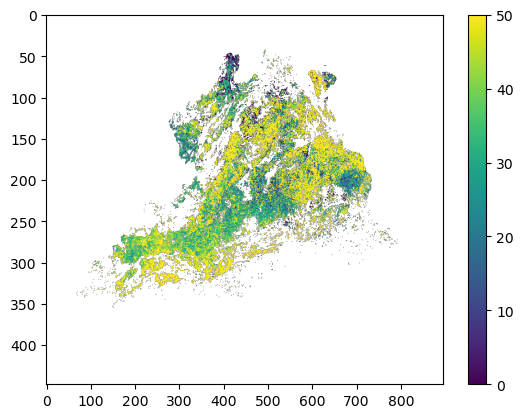

In [25]:
plt.imshow(calibrated.calibration.values[:,:,0], cmap="viridis", aspect="auto", vmin=0, vmax=50)
plt.colorbar()
plt.show()

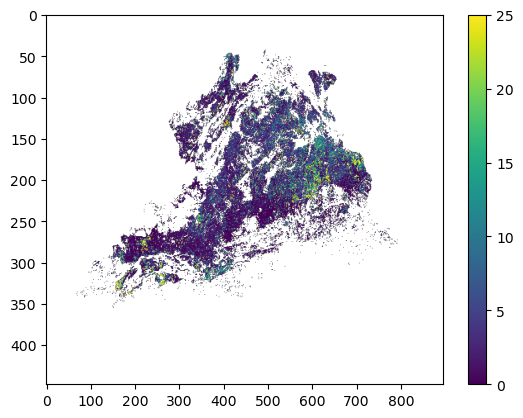

In [26]:
plt.imshow(calibrated.calibration.values[:,:,1], cmap="viridis", aspect="auto", vmin=0, vmax=25)
plt.colorbar()
plt.show()

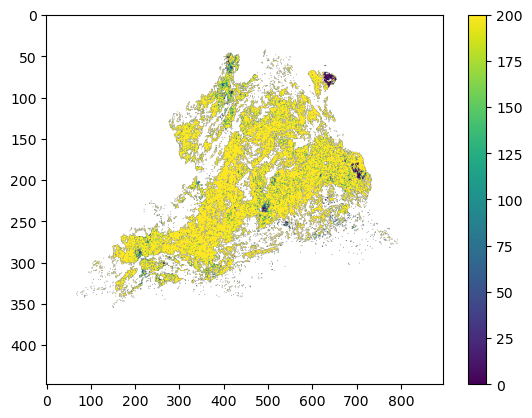

In [27]:
plt.imshow(calibrated.calibration.values[:,:,2], cmap="viridis", aspect="auto", vmin=0, vmax=200)
plt.colorbar()
plt.show()

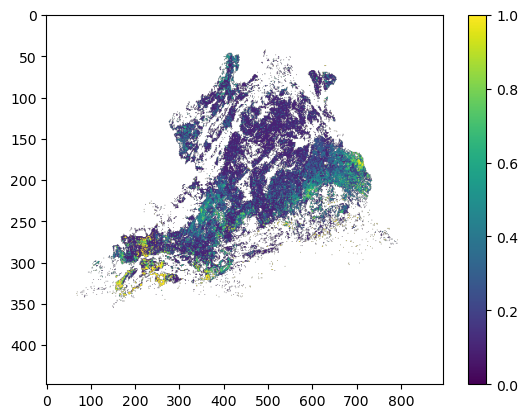

In [28]:
plt.imshow(calibrated.calibration.values[:,:,3], cmap="viridis", aspect="auto", vmin=0, vmax=1)
plt.colorbar()
plt.show()

In [29]:
arr_reshaped = calibrated.calibration.values.reshape(-1, 4)

In [30]:
unique_param_sets = np.unique(arr_reshaped, axis=0)

print(f"Number of unique parameter sets: {len(unique_param_sets)}")
print(unique_param_sets)

Number of unique parameter sets: 400863
[[0.00000000e+00 1.00000000e-02 5.21009004e+02 5.45112464e-01]
 [0.00000000e+00 1.00000000e-02 5.50451754e+02 4.52317747e-01]
 [0.00000000e+00 1.00000000e-02 6.71682174e+02 7.50106186e-01]
 ...
 [           nan            nan            nan            nan]
 [           nan            nan            nan            nan]
 [           nan            nan            nan            nan]]


In [31]:
unique_param_sets_no_nan = unique_param_sets[~np.isnan(unique_param_sets).any(axis=1)]
print(f"Unique parameter sets without NaNs: {len(unique_param_sets_no_nan)}")
print(unique_param_sets_no_nan)

Unique parameter sets without NaNs: 55725
[[0.00000000e+00 1.00000000e-02 5.21009004e+02 5.45112464e-01]
 [0.00000000e+00 1.00000000e-02 5.50451754e+02 4.52317747e-01]
 [0.00000000e+00 1.00000000e-02 6.71682174e+02 7.50106186e-01]
 ...
 [2.00000000e+02 5.00000000e+01 8.00000000e+02 6.35759706e-01]
 [2.00000000e+02 5.00000000e+01 8.00000000e+02 7.90187244e-01]
 [2.00000000e+02 5.00000000e+01 8.00000000e+02 1.32394902e+00]]
